## Technical Analytics
- SMA, EMA, MACD, RSI, Bollinger, etc
- Actual production decisions should be based on:
  - Train on historical data (backtest)
  - Test on recent data (predict)
  - Where strategy beats buy & hold
    - Foward the tickers and buy / sell
    - Should be weighted by a risk layer

In [1]:
# Imports
# Standard
from datetime import datetime

# Data
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("bright")

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
    }
)

# Financial
from openbb import obb

# Optimization
from scipy import optimize

# Printing
from rich import print

# Parallelization
from concurrent.futures import ThreadPoolExecutor, as_completed

## 1.0 - SMA
- Optimize golden cross strategy
- Apply to stocks in a screener

BNH: 11.787979036782392,
    SIGNAL: 76.10603587283144

,price,symbol,sma_s,sma_l,signal,log_return,signal_return
date,,,,,,,
2020-08-21,14.508000,MSTR,12.35530,12.790728,0,NaN,NaN
2020-08-24,14.858000,MSTR,12.41642,12.793364,0,0.023838,0.0
2020-08-25,14.696000,MSTR,12.46500,12.795457,0,-0.010963,-0.0
2020-08-26,14.606000,MSTR,12.51320,12.796574,0,-0.006143,-0.0
2020-08-27,14.652000,MSTR,12.56278,12.798210,0,0.003144,0.0
...,...,...,...,...,...,...,...
2026-04-20,170.809998,MSTR,134.87720,204.683272,0,0.025436,0.0
2026-04-21,163.970001,MSTR,135.45800,203.583951,0,-0.040868,-0.0
2026-04-22,179.360001,MSTR,136.27640,202.599507,0,0.089711,0.0


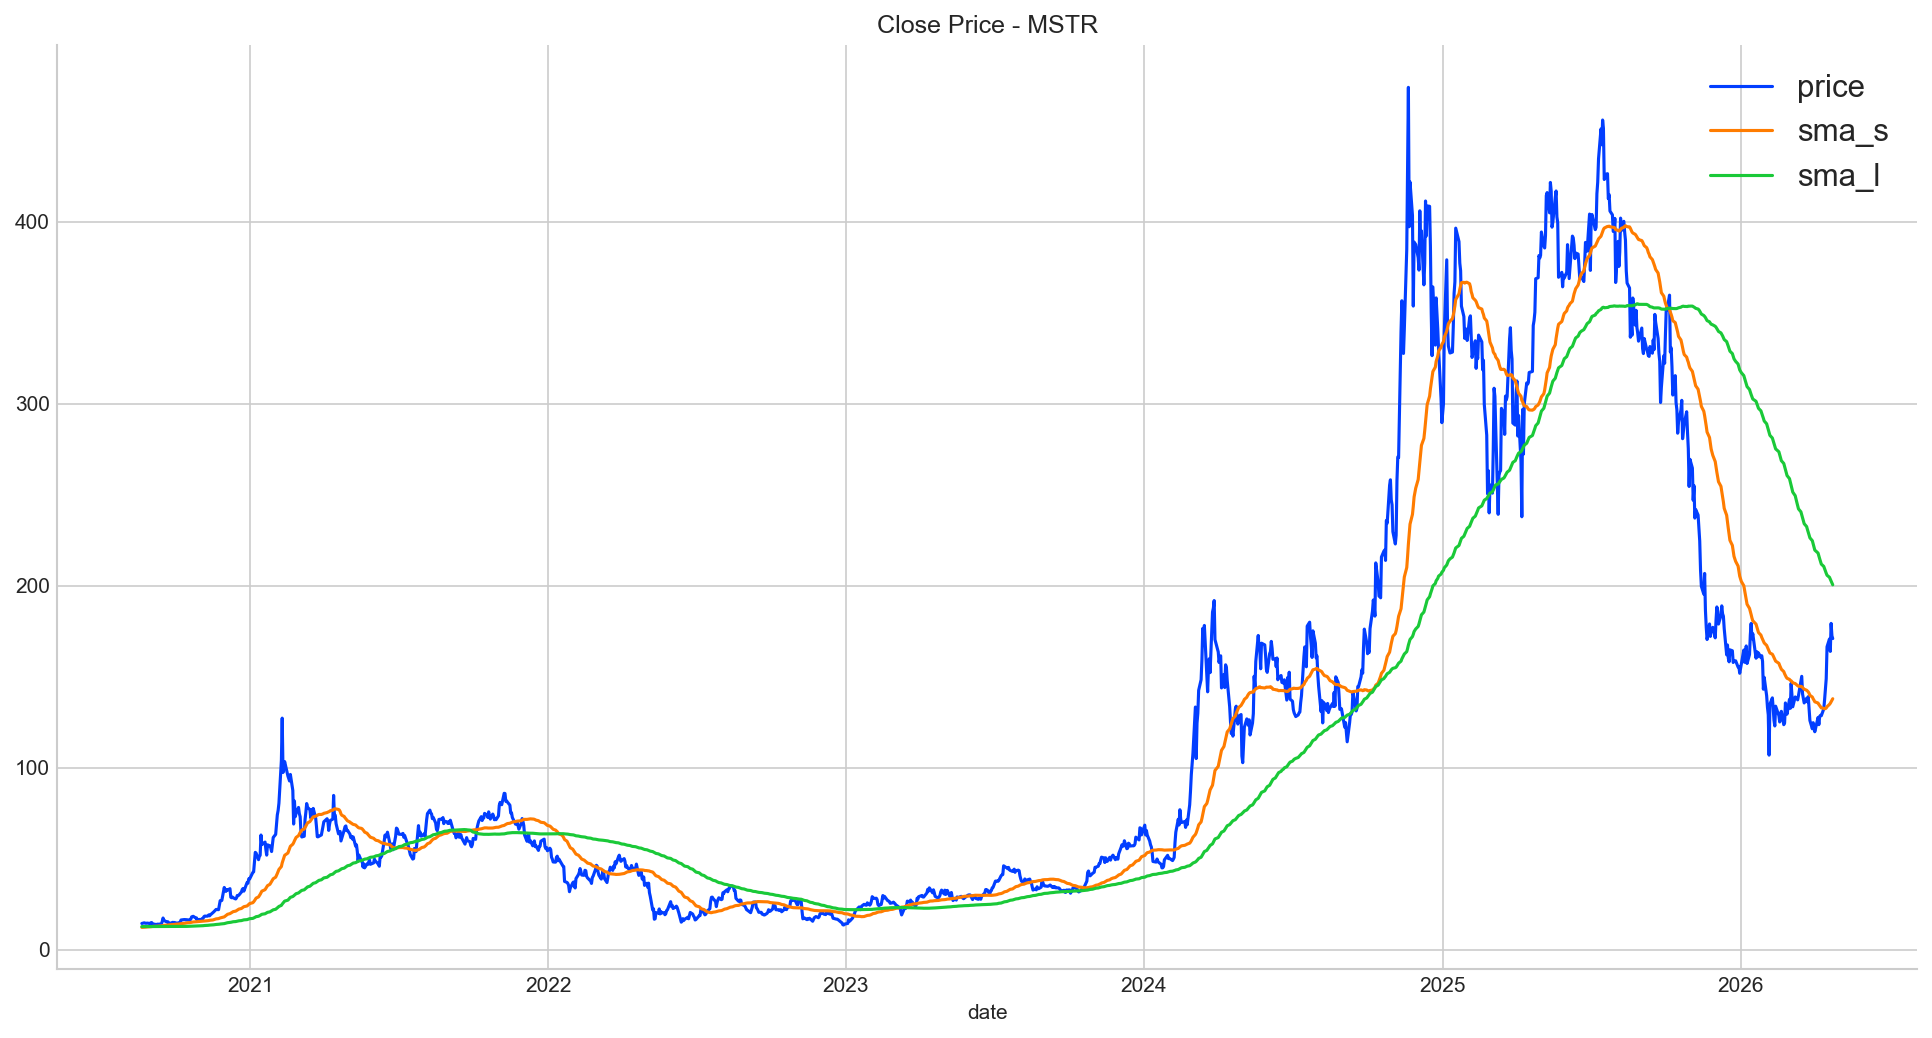

In [2]:
# Single stock
SYMBOL = "MSTR"
TODAY = datetime.today().strftime("%Y-%m-%d")

# Moving averages
SMA_S = 50
SMA_L = 162

df = (
    obb.equity.price.historical(symbol=SYMBOL, start_date="2020-01-01", end_date=TODAY)
    .to_dataframe()
    .drop_duplicates()
    .assign(symbol=SYMBOL)
    .loc[:, ["close", "symbol"]]
    .rename(columns={"close": "price"})
)

# Moving averages, signal (buy / sell), returns, cumulative returns
df["sma_s"] = df["price"].rolling(SMA_S).mean()
df["sma_l"] = df["price"].rolling(SMA_L).mean()
df.dropna(subset=["sma_s", "sma_l"], inplace=True)
df["signal"] = np.where(df["sma_s"] > df["sma_l"], 1, 0)
df["log_return"] = np.log(df["price"].div(df["price"].shift(1)))
# Decision to buy or sell basesd on prior day's signal
df["signal_return"] = df["signal"].shift(1) * df["log_return"]

# Buy & hold vs. Signal based
print(f"""
    BNH: {np.exp(df["log_return"].sum())},
    SIGNAL: {np.exp(df["signal_return"].sum())}
""")

display(df)

# Visualize
df.drop(["symbol", "signal", "log_return", "signal_return"], axis=1).plot(
    figsize=(16, 8), fontsize=10
)
plt.title(f"Close Price - {SYMBOL}")
plt.legend(fontsize=15)
plt.show()

In [3]:
# Universe
US_EXCHANGES = {"NMS", "NGM", "NCM", "NYQ", "ASE"}

# Starting tickers
screener_df = (
    obb.equity.screener(limit=500)
    .to_dataframe()
    .pipe(lambda d: d[d["exchange"].isin(US_EXCHANGES)])
    .query("price > 20")
    .nlargest(100, columns="volume")
)
tickers = screener_df["symbol"].unique().tolist()

# Historical prices
TODAY = datetime.today().strftime("%Y-%m-%d")

# Retrieve the data
df = (
    obb.equity.price.historical(symbol=tickers, start_date="2022-01-01", end_date=TODAY)
    .to_dataframe()
    .drop_duplicates()
    .rename(columns={"close": "price"})[["price", "symbol"]]
)
df.index = pd.to_datetime(df.index)

# Walk-forward split
TRAIN_END = "2024-12-31"
TEST_START = "2025-01-01"

SMA_S_RANGE = (10, 60, 1)
SMA_L_RANGE = (100, 252, 1)


def sma_cumulative_return(
    data: pd.DataFrame, sma_s: int, sma_l: int, eval_from: str = None
) -> float:
    """Cumulative GC strategy return. SMAs computed on full data for warmup, performance measured from eval_from."""
    d = data.copy()
    d["sma_s"] = d["price"].rolling(sma_s).mean()
    d["sma_l"] = d["price"].rolling(sma_l).mean()
    d["signal"] = np.where(d["sma_s"] > d["sma_l"], 1, 0)
    d["log_return"] = np.log(d["price"].div(d["price"].shift(1)))
    d["signal_return"] = d["signal"].shift(1) * d["log_return"]
    if eval_from:
        d = d.loc[eval_from:]
    return np.exp(
        d.dropna(subset=["sma_s", "sma_l", "signal_return"])["signal_return"].sum()
    ).item()


def bnh_cumulative_return(data: pd.DataFrame, eval_from: str = None) -> float:
    """Cumulative buy-and-hold return over the given period."""
    d = data.loc[eval_from:] if eval_from else data.copy()
    return np.exp(np.log(d["price"].div(d["price"].shift(1))).dropna().sum()).item()


def objective(sma_windows: tuple, data: pd.DataFrame) -> float:
    """Negated strategy return for minimisation by scipy.optimize.brute."""
    return -sma_cumulative_return(data, int(sma_windows[0]), int(sma_windows[1]))


def evaluate_ticker(symbol: str) -> tuple[str, dict]:
    """Run walk-forward SMA optimisation for a single ticker. Returns symbol and result dict."""
    ticker_df = df[df["symbol"] == symbol].copy()
    train_data = ticker_df.loc[:TRAIN_END]

    if len(train_data) < 252:
        return symbol, None

    opt = optimize.brute(
        func=objective,
        ranges=(SMA_S_RANGE, SMA_L_RANGE),
        args=(train_data,),
        finish=None,
    )
    sma_s_opt, sma_l_opt = int(opt[0]), int(opt[1])

    gc_test = sma_cumulative_return(
        ticker_df, sma_s_opt, sma_l_opt, eval_from=TEST_START
    )
    bnh_test = bnh_cumulative_return(ticker_df, eval_from=TEST_START)

    return symbol, {
        "opt_windows": (sma_s_opt, sma_l_opt),
        "gc_test": round(gc_test, 4),
        "bnh_test": round(bnh_test, 4),
        "gc_beats_bnh": gc_test > bnh_test,
    }


results = {}
with ThreadPoolExecutor() as executor:
    futures = {executor.submit(evaluate_ticker, s): s for s in df["symbol"].unique()}
    for future in as_completed(futures):
        symbol, result = future.result()
        if result:
            results[symbol] = result

results_df = pd.DataFrame(results).T.sort_values("gc_test", ascending=False)
display(results_df)

candidates = results_df[results_df["gc_beats_bnh"]].index.tolist()
print(f"GC outperforms BNH out-of-sample: {candidates}")

,opt_windows,gc_test,bnh_test,gc_beats_bnh
LITE,"(32, 200)",7.988,10.2995,False
TTMI,"(10, 212)",4.4993,6.0622,False
VIAV,"(45, 228)",4.129,4.7277,False
MU,"(52, 243)",4.1089,5.6879,False
INTC,"(47, 107)",3.5409,4.0821,False
...,...,...,...,...
AMSC,"(54, 249)",0.6099,1.9366,False
NOW,"(40, 249)",0.6096,0.4276,True
TTD,"(41, 198)",0.5983,0.2036,True
NVO,"(36, 116)",0.5902,0.4704,True


GC outperforms BNH out-of-sample: ['TER', 'AMKR', 'BBIO', 'AGI', 'COHU', 'SLB', 'ENTG', 'ESI', 'HIMS', 'SE', 'SAP',
'PG', 'SWKS', 'ADBE', 'RELY', 'TEAM', 'CAVA', 'TOST', 'XYZ', 'GTLB', 'DOCU', 'FLUT', 'NTNX', 'WDAY', 'INTU', 
'TECH', 'IOT', 'CRM', 'DOCS', 'DT', 'NOW', 'TTD', 'NVO']